## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import kendalltau, pearsonr
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    dtw, 
    format_stats, 
    mean_center, 
    show_source
)

## Functions

In [2]:
def rdp(trajectory, epsilon, metric='euclidean', return_indices=False):
    """
    Simplify an n-dimensional trajectory using the Ramer-Douglas-Peucker algorithm.

    Parameters
    ----------
    trajectory : numpy.ndarray
        A (timepoints x features) matrix representing the curve to simplify.
    epsilon : float
        Maximum allowed distance from a point to the simplified curve. Points
        farther than epsilon from the line segment connecting their neighbors
        are retained.
    metric : str or callable
        Distance metric used when computing point-to-segment distances.
        Accepts any distance name supported by scipy.spatial.distance.cdist
        (e.g. 'euclidean', 'cosine', 'correlation') or a callable with
        signature f(u, v) -> float.
    return_indices : bool, default False
        If True, return a tuple (simplified_trajectory, indices) where
        indices is a 1D array of the retained point indices into the original
        trajectory. If False, return only the simplified trajectory.

    Returns
    -------
    numpy.ndarray or tuple
        The simplified trajectory, or (simplified_trajectory, indices) when
        return_indices is True.
    """
    def _dist(points, start, end):
        """
        Compute the distance from each point in `points` to the line segment
        defined by `start` and `end`.

        The perpendicular foot is clamped to the segment so that points past
        either endpoint are measured to the nearest endpoint instead.
        """
        segment = end - start
        seg_len_sq = np.dot(segment, segment)

        if seg_len_sq == 0:
            # Degenerate segment: start == end; distance is point-to-point.
            if callable(metric):
                return np.array([metric(p, start) for p in points])
            return cdist(points, start[np.newaxis], metric=metric).ravel()

        # Scalar projection of each point onto the segment, clamped to [0, 1].
        t = np.clip(
            np.dot(points - start, segment) / seg_len_sq,
            0.0, 1.0
        )                                           # shape (n,)
        projections = start + t[:, np.newaxis] * segment   # shape (n, d)

        if callable(metric):
            return np.array([metric(p, proj) for p, proj in zip(points, projections)])
        # cdist expects 2-D arrays.
        return cdist(points, projections, metric=metric).diagonal()

    def _rdp_indices(indices):
        """
        Recursively collect the indices of points to keep.
        Works on a view into the global `trajectory` array.
        """
        if len(indices) <= 2:
            return list(indices)

        start = trajectory[indices[0]]
        end   = trajectory[indices[-1]]
        inner = indices[1:-1]

        dists = _dist(trajectory[inner], start, end)
        max_idx = np.argmax(dists)
        max_dist = dists[max_idx]

        if max_dist > epsilon:
            pivot = max_idx + 1   # position within `indices`
            left  = _rdp_indices(indices[:pivot + 1])
            right = _rdp_indices(indices[pivot:])
            # Merge, avoiding the duplicate at the pivot.
            return left[:-1] + right
        else:
            return [indices[0], indices[-1]]

    trajectory = np.asarray(trajectory)
    kept = _rdp_indices(list(range(len(trajectory))))
    kept = np.array(kept)

    simplified = trajectory[kept]
    return (simplified, kept) if return_indices else simplified

In [3]:
show_source(dtw)

## Load data

In [4]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [5]:
# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

In [6]:
EPSILON_STEP = 0.01
EPSILONS = np.arange(0, 2, EPSILON_STEP).round(2)

df = pd.DataFrame(index=range(len(participants) * (len(EPSILONS))), 
                  columns=('participant', 
                           'epsilon', 
                           'n_events_removed', 
                           'n_events_remaining', 
                           'warp_cost'))
df['participant'] = np.repeat([f'P{p.sub_n}' for p in participants], len(EPSILONS))
df['epsilon'] = np.tile(EPSILONS, len(participants))

pbar = tqdm(total=len(df), leave=False)
df_ix = 0
for p_ix in range(len(participants)):
    imm_events = imm_events_centered[p_ix]
    del_events = del_events_centered[p_ix]

    # un-simplified alignment cost (baseline)
    n_events_orig = len(imm_events)
    n_events_remaining = n_events_orig
    n_events_removed = 0
    warp_cost = dtw(imm_events, del_events, metric='cosine', norm_cost=True)[0]
    df.loc[df_ix, 'n_events_removed':'warp_cost'] = (n_events_removed, 
                                                     n_events_remaining, 
                                                     warp_cost)
    df_ix += 1
    pbar.update()
    
    for epsilon in EPSILONS[1:]:
        imm_simplified = rdp(imm_events, epsilon=epsilon, metric='cosine')
        if len(imm_simplified) != n_events_remaining:
            n_events_remaining = len(imm_simplified)
            n_events_removed = n_events_orig - n_events_remaining
            warp_cost = dtw(imm_simplified, 
                            del_events, 
                            metric='cosine', 
                            norm_cost=True)[0]
        
        df.loc[df_ix, 'n_events_removed':'warp_cost'] = (n_events_removed, 
                                                         n_events_remaining, 
                                                         warp_cost)
        df_ix += 1
        pbar.update()
        
        if n_events_remaining == 2:
            last_p_row = df.index[df['participant'] == f'P{p_ix + 1}'][-1].item()
            df.loc[
                df_ix:last_p_row, 'n_events_removed':'warp_cost'
            ] = (n_events_removed, n_events_remaining, warp_cost)
            df_ix = last_p_row + 1
            pbar.update(df_ix - pbar.n)
            break
            
df = df.astype({'participant': str, 
                'epsilon': float, 
                'n_events_removed': int, 
                'n_events_remaining': int, 
                'warp_cost': float})
pbar.close()

  0%|          | 0/10600 [00:00<?, ?it/s]

In [52]:
best_alignments = (
    df.loc[
        df.groupby('participant')['warp_cost'].idxmin(), [
            'participant', 
            'epsilon', 
            'n_events_removed', 
            'n_events_remaining', 
            'warp_cost'
        ]
    ]
    .sort_values(
        by='participant', key=lambda pid: pid.str.removeprefix('P').astype(int)
    )
    .reset_index(drop=True)
)

best_alignments['n_events_imm'] = [len(p.events['atlep1']) for p in participants]
best_alignments['n_events_del'] = [len(p.events['delayed']) for p in participants]
best_alignments['n_events_decrease'] = best_alignments['n_events_imm'] - best_alignments['n_events_del']

best_alignments

,participant,epsilon,n_events_removed,n_events_remaining,warp_cost,n_events_imm,n_events_del,n_events_decrease
0,P1,0.42,1,22,0.558993,23,19,4
1,P2,0.00,0,14,0.549072,14,16,-2
2,P3,0.29,1,19,0.468923,20,18,2
3,P4,0.00,0,19,0.397291,19,18,1
4,P5,0.00,0,18,0.466080,18,19,-1
5,P6,0.52,4,14,0.510251,18,15,3
6,P7,0.82,8,9,0.669708,17,12,5
7,P8,0.00,0,19,0.373728,19,19,0
8,P9,0.59,3,14,0.596358,17,15,2
9,P10,0.00,0,14,0.468798,14,16,-2


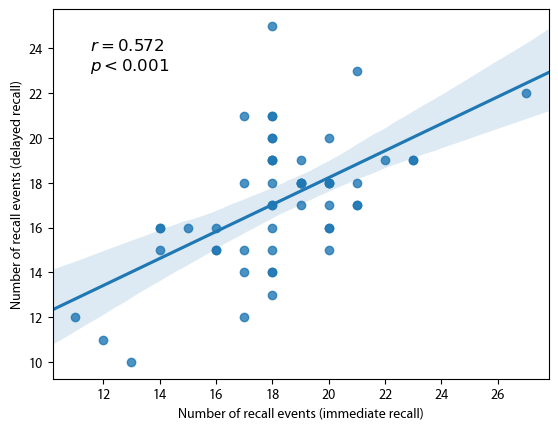

In [8]:
ax = sns.regplot(best_alignments, 
                 x='n_events_imm', 
                 y='n_events_del', 
                 truncate=False)
r, p = pearsonr(best_alignments['n_events_imm'], best_alignments['n_events_del'])
stats_fmt = format_stats(r, p, 'r')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('Number of recall events (immediate recall)')
ax.set_ylabel('Number of recall events (delayed recall)')
plt.show()

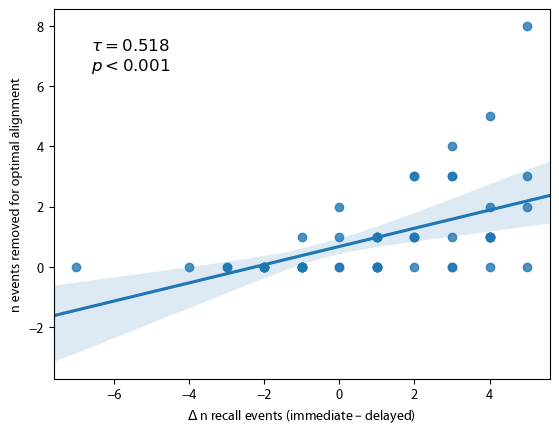

In [9]:
ax = sns.regplot(best_alignments, 
                 x='n_events_decrease',
                 y='n_events_removed', 
                 truncate=False)
tau, p = kendalltau(best_alignments['n_events_decrease'], 
                    best_alignments['n_events_removed'])
stats_fmt = format_stats(tau, p, '\\tau')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('$\\Delta$ n recall events (immediate – delayed)')
ax.set_ylabel('n events removed for optimal alignment')
plt.show()

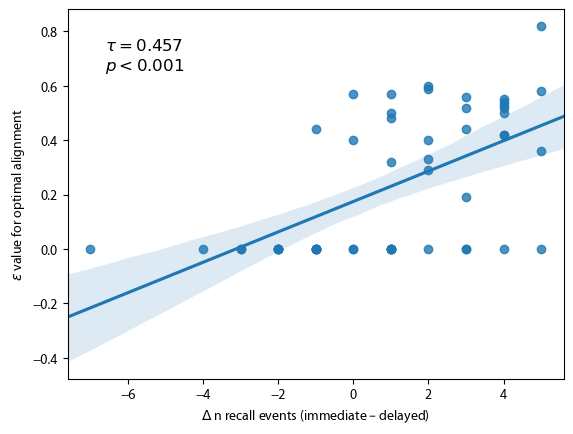

In [10]:
ax = sns.regplot(best_alignments, 
                 x='n_events_decrease', 
                 y='epsilon', 
                 truncate=False)
tau, p = kendalltau(best_alignments['n_events_decrease'], 
                    best_alignments['epsilon'])
stats_fmt = format_stats(tau, p, '\\tau')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('$\\Delta$ n recall events (immediate – delayed)')
ax.set_ylabel('$\\epsilon$ value for optimal alignment')
plt.show()

y-axis: epsilon

x-axis: event #

cell: prop of participants for whom that event was dropped for that epsilon

In [53]:
best_alignments

,participant,epsilon,n_events_removed,n_events_remaining,warp_cost,n_events_imm,n_events_del,n_events_decrease
0,P1,0.42,1,22,0.558993,23,19,4
1,P2,0.00,0,14,0.549072,14,16,-2
2,P3,0.29,1,19,0.468923,20,18,2
3,P4,0.00,0,19,0.397291,19,18,1
4,P5,0.00,0,18,0.466080,18,19,-1
5,P6,0.52,4,14,0.510251,18,15,3
6,P7,0.82,8,9,0.669708,17,12,5
7,P8,0.00,0,19,0.373728,19,19,0
8,P9,0.59,3,14,0.596358,17,15,2
9,P10,0.00,0,14,0.468798,14,16,-2


In [48]:
# newcols = [
#     'ep_events_removed_rdp', 
#     'ep_events_removed_real', 
#     'ep_events_added_real',
#     'ep_events_recalled_imm_only',
#     'ep_events_recalled_del_only'
# ]
# best_alignments[newcols] = np.nan
# for col in newcols:
#     best_alignments[col] = best_alignments[col].astype(object)
    
    
# for row_ix, row in best_alignments.iterrows():
#     p_ix = int(row['participant'].removeprefix('P')) - 1
#     p = participants[p_ix]
#     imm_events = imm_events_centered[p_ix]
#     imm_simplified, rec_events_retained = rdp(imm_events, epsilon=row['epsilon'], metric='cosine', return_indices=True)
    
#     ep_events_dropped_rdp = np.delete(p.event_matches['atlep1'], rec_events_retained)
#     best_alignments.at[row_ix, 'ep_events_removed_rdp'] = ep_events_dropped_rdp.tolist()
    
    
#     event_match_counts_imm = np.zeros(len(atlep1.events), dtype=int)
#     events_recalled_imm, n_matches_imm = np.unique(p.event_matches['atlep1'], return_counts=True)
#     event_match_counts_imm[events_recalled_imm] += n_matches_imm
    
#     event_match_counts_del = np.zeros(len(atlep1.events), dtype=int)
#     events_recalled_del, n_matches_del = np.unique(p.event_matches['delayed'], return_counts=True)
#     event_match_counts_del[events_recalled_del] += n_matches_del
    
#     removed_real = []
#     added_real = []
#     for ep_ev_ix in range(len(atlep1.events)):
#         removed_real.extend([ep_ev_ix] * (event_match_counts_imm[ep_ev_ix] - event_match_counts_del[ep_ev_ix]))
#         added_real.extend([ep_ev_ix] * (event_match_counts_del[ep_ev_ix] - event_match_counts_imm[ep_ev_ix]))
        
#     best_alignments.at[row_ix, 'ep_events_removed_real'] = removed_real
#     best_alignments.at[row_ix, 'ep_events_added_real'] = added_real
    
#     best_alignments.at[row_ix, 'ep_events_recalled_imm_only'] = np.setdiff1d(
#         events_recalled_imm, events_recalled_del
#     ).tolist()
#     best_alignments.at[row_ix, 'ep_events_recalled_del_only'] = np.setdiff1d(
#         events_recalled_del, events_recalled_imm
#     ).tolist()
        
# for col in newcols:
#     best_alignments[col] = best_alignments[col].apply(np.array, dtype=int)

In [138]:
newcols = [
    'rdp_pred_forgotten', 
    'true_forgotten',
    'true_positives',
    'false_positives',
    'true_negatives',
    'false_negatives'
]
best_alignments[newcols] = np.nan
best_alignments[['rdp_pred_forgotten', 'true_forgotten']] = best_alignments[
    ['rdp_pred_forgotten', 'true_forgotten']
].astype(object)


for ix, row in best_alignments.iterrows():
    p = participants[ix]
    imm_events = imm_events_centered[ix]
    imm_event_matches = p.event_matches['atlep1']
    del_event_matches = p.event_matches['delayed']
    
    imm_simplified, rec_events_retained = rdp(imm_events, 
                                              epsilon=row['epsilon'], 
                                              metric='cosine', 
                                              return_indices=True)
    ep_events_dropped_rdp = np.delete(imm_event_matches, rec_events_retained)
    pred_forgotten = np.unique(ep_events_dropped_rdp).tolist()
    # events should be deduplicated for analysis, but check whether any 
    # duplicates exist in the first place
    np.testing.assert_array_equal(sorted(ep_events_dropped_rdp), pred_forgotten)
    best_alignments.at[ix, 'rdp_pred_forgotten'] = pred_forgotten
    
    # exclude first & last immediate recall events since RDP will never
    # remove first or last point
    imm_rec_counts = Counter(imm_event_matches[1:-1].tolist())
    del_rec_counts = Counter(del_event_matches.tolist())
    true_forgotten = list((imm_rec_counts - del_rec_counts).keys())
    best_alignments.at[ix, 'true_forgotten'] = true_forgotten
    
    n_tp = n_fp = n_tn = n_fn = 0
    
    for ep_ev in imm_rec_counts.keys():
        pred_f = ep_ev in pred_forgotten
        true_f = ep_ev in true_forgotten
        
        if pred_f:
            if true_f:
                n_tp += 1
            else:
                n_fp += 1
        elif true_f:
            n_fn += 1
        else:
            n_tn += 1
            
    best_alignments.loc[ix, 'true_positives':'false_negatives'] = n_tp, n_fp, n_tn, n_fn


best_alignments[
    ['true_positives', 'false_positives', 'true_negatives', 'false_negatives']
] = best_alignments[
    ['true_positives', 'false_positives', 'true_negatives', 'false_negatives']
].astype(int)

In [151]:
best_alignments

,participant,epsilon,n_events_removed,n_events_remaining,warp_cost,n_events_imm,n_events_del,n_events_decrease,rdp_pred_forgotten,true_forgotten,true_positives,false_positives,true_negatives,false_negatives
0,P1,0.42,1,22,0.558993,23,19,4,[1],"[4, 10, 13]",0,1,14,3
1,P2,0.00,0,14,0.549072,14,16,-2,[],"[9, 12]",0,0,10,2
2,P3,0.29,1,19,0.468923,20,18,2,[9],"[9, 13]",1,0,16,1
3,P4,0.00,0,19,0.397291,19,18,1,[],"[13, 14]",0,0,14,2
4,P5,0.00,0,18,0.466080,18,19,-1,[],"[4, 12, 13]",0,0,13,3
5,P6,0.52,4,14,0.510251,18,15,3,"[5, 8, 10, 15]","[4, 7, 8]",1,3,10,2
6,P7,0.82,8,9,0.669708,17,12,5,"[2, 3, 6, 9, 13, 14, 15, 17]","[2, 6, 15, 14, 16, 17]",5,3,5,1
7,P8,0.00,0,19,0.373728,19,19,0,[],[],0,0,17,0
8,P9,0.59,3,14,0.596358,17,15,2,"[4, 7, 16]","[6, 10]",0,3,10,2
9,P10,0.00,0,14,0.468798,14,16,-2,[],[18],0,0,11,1


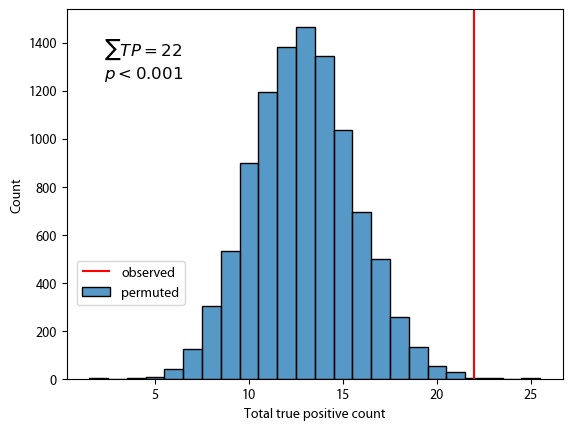

In [217]:
# number of immediate recall events (excluding endpoints)
N = best_alignments.loc[:, 'true_positives':'false_negatives'].sum(axis=1).to_numpy()
# number of events actually forgotten
R = best_alignments[['true_positives', 'false_negatives']].sum(axis=1).to_numpy()
# number of events predicted to be forgotten
P = best_alignments[['true_positives', 'false_positives']].sum(axis=1).to_numpy()
# number of participants
K = len(best_alignments)

n_perms = 10_000
rng = np.random.default_rng(0)
draws = rng.hypergeometric(R, N - R, P, size=(n_perms, K))

obs_tpsum = best_alignments['true_positives'].sum()
null_tpsums = draws.sum(axis=1)
p = ((null_tpsums >= obs_tpsum).sum() + 1) / (n_perms + 1)

ax = sns.histplot(null_tpsums, discrete=True, label='permuted')
ax.set_ylim(ax.get_ylim())
ax.vlines(obs_tpsum, *ax.get_ylim(), color='r', label='observed')
ax.legend(loc=(0.02, 0.2))
stats_fmt = format_stats(obs_tpsum, p, '\\sum TP', n_decimals_stat=0)
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('Total true positive count')
plt.show()

In [29]:
build_contingency(best_alignments, participants, exclude_endpoints=True)[0]

,participant,idx,TP,FP,FN,TN,n_pred,n_real,pool
0,P000,0,0,1,3,14,1,3,18
1,P001,1,0,0,2,10,0,2,12
2,P002,2,1,0,1,16,1,2,18
3,P003,3,0,0,2,14,0,2,16
4,P004,4,0,0,3,13,0,3,16
5,P005,5,1,3,2,10,4,3,16
6,P006,6,5,3,1,5,8,6,14
7,P007,7,0,0,0,17,0,0,17
8,P008,8,0,3,2,10,3,2,15
9,P009,9,0,0,1,11,0,1,12


In [50]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from collections import Counter


# --------------------------------------------------------------------------- #
# 1. build per-participant 2x2 tables + long-format frame for the mixed model
# --------------------------------------------------------------------------- #
def build_contingency(best_alignments, participants,
                      unit="item",
                      pred_col="ep_events_removed_rdp",
                      imm_key="atlep1", del_key="delayed",
                      exclude_endpoints=False):
    """
    Returns
      tabs    : DataFrame, one row/participant, columns TP, FP, FN, TN, ...
                Orientation: rows = predicted (1,0), cols = actual (1,0), so
                TP = predicted & forgotten, and OR > 1 means positive association.
      long_df : DataFrame (unit='item' only) with one row per (participant,item):
                columns participant, item, predicted, actual. None for occurrence.
      notes   : list of data-sanity warnings.

    The 'actually forgotten' multiset is recomputed HERE from the raw immediate
    and delayed event matches -- forgotten(e) = max(0, imm_count(e) - del_count(e))
    -- rather than read from a precomputed column. This guarantees the pool and
    the labels share ONE definition, which is what prevents the pool and the
    'actual' cells from drifting apart. `pred_col` (the RDP-removed episode
    events) is still consumed as given.

    exclude_endpoints : if True, drop the FIRST and LAST occurrences of each
        participant's immediate-recall sequence before doing anything else.
        Rationale: RDP structurally never removes the endpoints of the immediate
        trajectory, so those two trials are not ones the method could ever have
        flagged; excluding them removes that free agreement. The exclusion is
        applied to the immediate sequence only (RDP never touches the delayed
        trajectory) and it flows into the pool, `predicted`, and `actual`
        simultaneously because all three are derived from `imm_used` below.
    """
    if unit not in ("item", "occurrence"):
        raise ValueError("unit must be 'item' or 'occurrence'")

    recs, long_rows, notes = [], [], []
    n = len(best_alignments)
    
    for i in range(n):
        row = best_alignments.iloc[i]
        p = participants[i]

        imm_full = p.event_matches[imm_key]
        del_full = p.event_matches[del_key]

        # Endpoint control: trim first & last IMMEDIATE occurrences only.
        assert imm_full.size >= 2
        imm_used = imm_full[1:-1]

        imm_c = Counter(imm_used.tolist())
        del_c = Counter(del_full.tolist())          # delayed kept FULL, never trimmed
        pred_c = Counter(row[pred_col].tolist())

        # actual-forgotten multiset, recomputed from the (possibly trimmed)
        # immediate counts vs the full delayed counts:
        real_c = Counter()
        for e, ci in imm_c.items():
            f = ci - del_c.get(e, 0)
            if f > 0:
                real_c[e] = f

        # sanity: predicted occurrences should fall within the immediate pool.
        stray = {it: pred_c[it] for it in pred_c if pred_c[it] > imm_c.get(it, 0)}
        if stray:
            notes.append(f"participant {i}: predicted events outside the "
                         f"immediate pool {stray} (pool expanded to include them; "
                         f"if exclude_endpoints=True this can mean RDP flagged an "
                         f"endpoint-matched event)")

        pool = set(imm_c) | set(pred_c) | set(real_c)
        assert pool == set(imm_c)
        TP = FP = FN = TN = 0

        for it in pool:
            a = 1 if real_c.get(it, 0) > 0 else 0     # actually forgotten?
            d = 1 if pred_c.get(it, 0) > 0 else 0     # predicted forgotten?
            if d and a:
                TP += 1
            elif d and not a:
                FP += 1
            elif a:
                FN += 1
            else:
                TN += 1
            long_rows.append({"participant": f"P{i:03d}",
                              "item": f"I{it}",
                              "predicted": d, "actual": a})


        recs.append(dict(participant=f"P{i:03d}", idx=i,
                         TP=TP, FP=FP, FN=FN, TN=TN,
                         n_pred=TP + FP, n_real=TP + FN, pool=TP + FP + FN + TN))

    tabs = pd.DataFrame(recs)
    long_df = pd.DataFrame(long_rows) if unit == "item" else None
    return tabs, long_df, notes


# --------------------------------------------------------------------------- #
# 3. Permutation test
# --------------------------------------------------------------------------- #
def permutation_test(tabs, n_perm=10000, seed=0,
                     statistic="pooled_TP", alternative="greater"):
    """
    Within each participant, hold the pool, the number actually forgotten, and
    the number predicted fixed, and randomly reassign which pool members are
    'predicted'. The induced null for each participant's true-positive count is
    Hypergeometric(pool, n_real, n_pred) -- this is the exact label-permutation
    null, not an approximation. Aggregate across participants and compare to the
    observed statistic.

    statistic : 'pooled_TP'  -> total true positives across participants
                'micro_mcc'  -> MCC of the pooled 2x2 table
    """
    rng = np.random.default_rng(seed)
    N = tabs.pool.to_numpy(int)
    R = tabs.n_real.to_numpy(int)           # actual positives per participant
    P = tabs.n_pred.to_numpy(int)           # predicted positives per participant
    K = len(N)

    draws = rng.hypergeometric(R, N - R, P, size=(n_perm, K))   # TP per perm/participant

    if statistic == "pooled_TP":
        obs = tabs.TP.sum()
        null = draws.sum(axis=1)
    elif statistic == "micro_mcc":
        obs = mcc_from_counts(tabs.TP.sum(), tabs.FP.sum(),
                              tabs.FN.sum(), tabs.TN.sum())
        TP = draws.sum(1)
        FP = P.sum() - TP
        FN = R.sum() - TP
        TN = N.sum() - TP - FP - FN
        with np.errstate(invalid="ignore", divide="ignore"):
            denom = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
            null = np.where(denom == 0, 0.0, (TP * TN - FP * FN) / denom)
    else:
        raise ValueError("statistic must be 'pooled_TP' or 'micro_mcc'")

    if alternative == "greater":
        p = (np.sum(null >= obs) + 1) / (n_perm + 1)
    elif alternative == "two-sided":
        centre = null.mean()
        p = (np.sum(np.abs(null - centre) >= abs(obs - centre)) + 1) / (n_perm + 1)
    else:
        raise ValueError("alternative must be 'greater' or 'two-sided'")

    return {"statistic": statistic, "observed": float(obs),
            "null_mean": float(np.mean(null)), "null_sd": float(np.std(null)),
            "p_value": float(p), "alternative": alternative, "n_perm": n_perm}


def run_all(best_alignments, participants, unit="item",
            n_perm=10000, seed=0, include_item_random_effect=True,
            exclude_endpoints=True):
    
    tabs, long_df, notes = build_contingency(
        best_alignments, participants, unit=unit,
        exclude_endpoints=exclude_endpoints)
    for m in notes:
        warnings.warn(m)

    pooled = tabs[["TP", "FP", "FN", "TN"]].sum()
    print(f"\nParticipants: {len(tabs)}   Pooled 2x2 "
          f"(rows=predicted 1/0, cols=actual 1/0):")
    print(f"    TP={pooled.TP}  FP={pooled.FP}")
    print(f"    FN={pooled.FN}  TN={pooled.TN}")
    print(f"    participants who forgot nothing:   {(tabs.n_real == 0).sum()}")
    print(f"    participants who predicted nothing:{(tabs.n_pred == 0).sum()}")

    # -- permutation --
    print("\n-- Permutation test (exact label-permutation null) --")
    for stat in ("pooled_TP", "micro_mcc"):
        r = permutation_test(tabs, n_perm=n_perm, seed=seed,
                             statistic=stat, alternative="greater")
        print(f"  {stat:10s}: observed={r['observed']:.3f}  "
              f"null={r['null_mean']:.3f}+/-{r['null_sd']:.3f}  "
              f"p(greater)={r['p_value']:.3e}")

    # -- mixed model (item unit only) --
    # Fit BOTH specifications and compare. The 'predicted' effect in
    # the first is your method's TOTAL predictive value; in the second
    # it is the value that REMAINS after conditioning on each event's
    # average forgettability (i.e. participant-specific prediction).
    # A large drop from model 1 to model 2 means the method mostly
    # tracks event-general forgettability rather than who forgets what.
    specs = [("actual ~ predicted + (1|participant)", False)]
    if include_item_random_effect:
        specs.append(
            ("actual ~ predicted + (1|participant) + (1|event)", True))
    for label, inc in specs:
        print(f"\n-- Mixed-effects logistic (pymer4): {label} --")
        try:
            m = glmm_pymer4(long_df, include_item=inc)
            # .result_fit is the fixed-effects table; because we fit
            # with exponentiate=True the 'predicted' row is the OR.
            print(m.result_fit)
            try:
                m.summary()
            except Exception:
                pass
        except ImportError:
            print("  pymer4 (or R/lme4/polars) not available - "
                  "skipping. See GEE fallback below.")
            break
        except Exception as e:
            print(f"  pymer4 call failed ({e}). GEE fallback below "
                  "needs no R.")

run_all(best_alignments, participants, exclude_endpoints=True)


Participants: 53   Pooled 2x2 (rows=predicted 1/0, cols=actual 1/0):
    TP=22  FP=31
    FN=108  TN=660
    participants who forgot nothing:   6
    participants who predicted nothing:27

-- Permutation test (exact label-permutation null) --
  pooled_TP : observed=22.000  null=12.901+/-2.711  p(greater)=7.999e-04
  micro_mcc : observed=0.185  null=0.061+/-0.037  p(greater)=7.999e-04

-- Mixed-effects logistic (pymer4): actual ~ predicted + (1|participant) --
shape: (2, 8)
┌─────────────┬──────────┬───────────┬──────────┬───────────┬────────────┬─────┬────────────┐
│ term        ┆ estimate ┆ std_error ┆ conf_low ┆ conf_high ┆ z_stat     ┆ df  ┆ p_value    │
│ ---         ┆ ---      ┆ ---       ┆ ---      ┆ ---       ┆ ---        ┆ --- ┆ ---        │
│ str         ┆ f64      ┆ f64       ┆ f64      ┆ f64       ┆ f64        ┆ f64 ┆ f64        │
╞═════════════╪══════════╪═══════════╪══════════╪═══════════╪════════════╪═════╪════════════╡
│ (Intercept) ┆ 0.159973 ┆ 0.018795  ┆ 0.127069 ┆ 0

In [153]:
"""
Testing whether predicted-forgotten items match actually-forgotten items.
==========================================================================

For each participant, every item they recalled in the immediate session is a
"trial" carrying two binary labels:
    actual    = 1 if the item was actually forgotten by the delay
    predicted = 1 if your method predicted it would be forgotten

That turns each participant into a 2x2 table and the question
("do the two lists tend to contain the same elements?") into
"is there a positive predicted<->actual association beyond chance,
accounting for the fact that base rates differ across participants?"

Two analysis units are provided:

  unit='item'        (PRIMARY) Deduplicate to unique items. An item is
                     "actually forgotten" if it appears at least once in the
                     removed-real multiset (i.e. immediate count > delayed
                     count), "predicted forgotten" if it appears in the rdp
                     list. Recommended because repeated recalls of the SAME
                     item are not independent trials; counting them as such
                     inflates N and significance. This also matches the
                     set-overlap framing of the question and is well-defined
                     for the mixed model.

  unit='occurrence'  (ROBUSTNESS) Keep the count-based multiset the method was
                     built against: an item recalled 3x immediately and 1x
                     delayed contributes 2 forgotten occurrences. Reported for
                     completeness; interpret its p-values cautiously because
                     repeated occurrences violate independence.

Tests implemented:
  * Cochran-Mantel-Haenszel (statsmodels) + manual MH cross-check (no deps)
  * Permutation test (exact label-permutation null via the hypergeometric)
  * Mixed-effects logistic regression (pymer4)  [+ statsmodels GEE fallback]
  * Effect sizes: micro/macro MCC (=phi), sensitivity, precision, per-
    participant Fisher exact tests

Data expected in your session:
  best_alignments : DataFrame, one row per participant, columns
      'ep_events_removed_rdp'  (predicted-forgotten indices; no dups in practice)
      'ep_events_removed_real' (actually-forgotten indices; may contain dups)
  participants    : list of Participant objects, SAME ORDER as the rows, with
      p.event_matches['atlep1']   = immediate-recall indices (may contain dups)
      p.event_matches['delayed']  = delayed-recall indices

Usage:
    from forgetting_prediction_tests import run_all
    run_all(best_alignments, participants)          # runs item + occurrence
"""

import warnings
import numpy as np
import pandas as pd
from scipy import stats
from collections import Counter


# --------------------------------------------------------------------------- #
# helpers
# --------------------------------------------------------------------------- #
def _as_int_array(x):
    a = np.asarray(x).ravel()
    return a.astype(int) if a.size else np.array([], dtype=int)


def mcc_from_counts(TP, FP, FN, TN):
    """Matthews correlation coefficient = phi coefficient for a 2x2 table."""
    TP, FP, FN, TN = map(float, (TP, FP, FN, TN))
    denom = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    return np.nan if denom == 0 else (TP * TN - FP * FN) / denom


# --------------------------------------------------------------------------- #
# 1. build per-participant 2x2 tables + long-format frame for the mixed model
# --------------------------------------------------------------------------- #
def build_contingency(best_alignments, participants,
                      unit="item",
                      pred_col="ep_events_removed_rdp",
                      imm_key="atlep1", del_key="delayed",
                      exclude_endpoints=False):
    """
    Returns
      tabs    : DataFrame, one row/participant, columns TP, FP, FN, TN, ...
                Orientation: rows = predicted (1,0), cols = actual (1,0), so
                TP = predicted & forgotten, and OR > 1 means positive association.
      long_df : DataFrame (unit='item' only) with one row per (participant,item):
                columns participant, item, predicted, actual. None for occurrence.
      notes   : list of data-sanity warnings.

    The 'actually forgotten' multiset is recomputed HERE from the raw immediate
    and delayed event matches -- forgotten(e) = max(0, imm_count(e) - del_count(e))
    -- rather than read from a precomputed column. This guarantees the pool and
    the labels share ONE definition, which is what prevents the pool and the
    'actual' cells from drifting apart. `pred_col` (the RDP-removed episode
    events) is still consumed as given.

    exclude_endpoints : if True, drop the FIRST and LAST occurrences of each
        participant's immediate-recall sequence before doing anything else.
        Rationale: RDP structurally never removes the endpoints of the immediate
        trajectory, so those two trials are not ones the method could ever have
        flagged; excluding them removes that free agreement. The exclusion is
        applied to the immediate sequence only (RDP never touches the delayed
        trajectory) and it flows into the pool, `predicted`, and `actual`
        simultaneously because all three are derived from `imm_used` below.
    """
    if unit not in ("item", "occurrence"):
        raise ValueError("unit must be 'item' or 'occurrence'")

    recs, long_rows, notes = [], [], []
    n = len(best_alignments)
    if len(participants) != n:
        raise ValueError("participants and best_alignments have different lengths")

    for i in range(n):
        row = best_alignments.iloc[i]
        p = participants[i]

        imm_full = _as_int_array(p.event_matches[imm_key])
        del_full = _as_int_array(p.event_matches[del_key])

        # Endpoint control: trim first & last IMMEDIATE occurrences only.
        if exclude_endpoints and imm_full.size >= 2:
            imm_used = imm_full[1:-1]
        else:
            imm_used = imm_full

        imm_c = Counter(imm_used.tolist())
        del_c = Counter(del_full.tolist())          # delayed kept FULL, never trimmed
        pred_c = Counter(_as_int_array(row[pred_col]).tolist())

        # actual-forgotten multiset, recomputed from the (possibly trimmed)
        # immediate counts vs the full delayed counts:
        real_c = Counter()
        for e, ci in imm_c.items():
            f = ci - del_c.get(e, 0)
            if f > 0:
                real_c[e] = f

        # sanity: predicted occurrences should fall within the immediate pool.
        stray = {it: pred_c[it] for it in pred_c if pred_c[it] > imm_c.get(it, 0)}
        if stray:
            notes.append(f"participant {i}: predicted events outside the "
                         f"immediate pool {stray} (pool expanded to include them; "
                         f"if exclude_endpoints=True this can mean RDP flagged an "
                         f"endpoint-matched event)")

        pool = set(imm_c) | set(pred_c) | set(real_c)
        TP = FP = FN = TN = 0

        for it in pool:
            if unit == "item":
                a = 1 if real_c.get(it, 0) > 0 else 0     # actually forgotten?
                d = 1 if pred_c.get(it, 0) > 0 else 0     # predicted forgotten?
                if d and a:        TP += 1
                elif d and not a:  FP += 1
                elif a:            FN += 1
                else:              TN += 1
                long_rows.append({"participant": f"P{i:03d}",
                                  "item": f"I{it}",
                                  "predicted": d, "actual": a})
            else:  # occurrence
                a = real_c.get(it, 0)
                d = pred_c.get(it, 0)
                m = max(imm_c.get(it, 0), a, d)           # occurrences of this item
                tp = min(a, d)
                TP += tp
                FP += d - tp
                FN += a - tp
                TN += m - tp - (d - tp) - (a - tp)

        recs.append(dict(participant=f"P{i:03d}", idx=i,
                         TP=TP, FP=FP, FN=FN, TN=TN,
                         n_pred=TP + FP, n_real=TP + FN, pool=TP + FP + FN + TN))

    tabs = pd.DataFrame(recs)
    long_df = pd.DataFrame(long_rows) if unit == "item" else None
    return tabs, long_df, notes


# --------------------------------------------------------------------------- #
# 2. Cochran-Mantel-Haenszel
# --------------------------------------------------------------------------- #
def cmh_statsmodels(tabs):
    """CMH test + Mantel-Haenszel common odds ratio via statsmodels."""
    from statsmodels.stats.contingency_tables import StratifiedTable
    tables = [np.array([[r.TP, r.FP], [r.FN, r.TN]], dtype=float)
              for r in tabs.itertuples()]
    st = StratifiedTable(tables)
    test = st.test_null_odds(correction=True)          # H0: common OR = 1
    out = {"cmh_stat": float(test.statistic),
           "cmh_p": float(test.pvalue),
           "or_mh": float(st.oddsratio_pooled)}
    try:
        lcb, ucb = st.oddsratio_pooled_confint()
        out["or_ci"] = (float(lcb), float(ucb))
    except Exception:
        pass
    # Homogeneity of the OR across participants (Tarone) is only defined for
    # strata whose 2x2 table has all four marginal totals > 0. Participants who
    # predicted nothing or forgot nothing have a zero margin -> undefined stratum
    # OR; feeding them to test_equal_odds() divides by zero (the NaN and
    # RuntimeWarnings). Restrict the homogeneity test to informative strata.
    # The CMH test and MH OR above correctly retain ALL strata.
    informative = tabs[(tabs.TP + tabs.FP > 0) & (tabs.FN + tabs.TN > 0) &
                       (tabs.TP + tabs.FN > 0) & (tabs.FP + tabs.TN > 0)]
    if len(informative) >= 2:
        tables_inf = [np.array([[r.TP, r.FP], [r.FN, r.TN]], dtype=float)
                      for r in informative.itertuples()]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                homog = StratifiedTable(tables_inf).test_equal_odds()
            out["homogeneity_stat"] = float(homog.statistic)
            out["homogeneity_p"] = float(homog.pvalue)
            out["homogeneity_n_strata"] = int(len(informative))
        except Exception:
            pass
    return out


def cmh_manual(tabs):
    """
    Dependency-free Mantel-Haenszel (validated to match statsmodels'
    test_null_odds(correction=True)). Handy as a cross-check.
    """
    a = tabs.TP.to_numpy(float); b = tabs.FP.to_numpy(float)
    c = tabs.FN.to_numpy(float); d = tabs.TN.to_numpy(float)
    n = a + b + c + d
    ok = n > 1
    Ea = np.where(ok, (a + b) * (a + c) / np.where(ok, n, 1), 0.0)
    Va = np.where(ok, (a + b) * (c + d) * (a + c) * (b + d)
                  / (np.where(ok, n, 1) ** 2 * np.where(ok, n - 1, 1)), 0.0)
    chi2 = (abs(a.sum() - Ea.sum()) - 0.5) ** 2 / Va.sum()
    p = stats.chi2.sf(chi2, 1)
    R = (a * d / np.where(ok, n, 1)).sum()
    S = (b * c / np.where(ok, n, 1)).sum()
    or_mh = R / S if S > 0 else np.inf
    return {"cmh_stat": float(chi2), "cmh_p": float(p), "or_mh": float(or_mh)}


# --------------------------------------------------------------------------- #
# 3. Permutation test
# --------------------------------------------------------------------------- #
def permutation_test(tabs, n_perm=10000, seed=0,
                     statistic="pooled_TP", alternative="greater"):
    """
    Within each participant, hold the pool, the number actually forgotten, and
    the number predicted fixed, and randomly reassign which pool members are
    'predicted'. The induced null for each participant's true-positive count is
    Hypergeometric(pool, n_real, n_pred) -- this is the exact label-permutation
    null, not an approximation. Aggregate across participants and compare to the
    observed statistic.

    statistic : 'pooled_TP'  -> total true positives across participants
                'micro_mcc'  -> MCC of the pooled 2x2 table
    """
    rng = np.random.default_rng(seed)
    N = tabs.pool.to_numpy(int)
    R = tabs.n_real.to_numpy(int)           # actual positives per participant
    P = tabs.n_pred.to_numpy(int)           # predicted positives per participant
    K = len(N)

    draws = rng.hypergeometric(R, N - R, P, size=(n_perm, K))   # TP per perm/participant

    if statistic == "pooled_TP":
        obs = tabs.TP.sum()
        null = draws.sum(axis=1)
    elif statistic == "micro_mcc":
        obs = mcc_from_counts(tabs.TP.sum(), tabs.FP.sum(),
                              tabs.FN.sum(), tabs.TN.sum())
        TP = draws.sum(1)
        FP = P.sum() - TP
        FN = R.sum() - TP
        TN = N.sum() - TP - FP - FN
        with np.errstate(invalid="ignore", divide="ignore"):
            denom = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
            null = np.where(denom == 0, 0.0, (TP * TN - FP * FN) / denom)
    else:
        raise ValueError("statistic must be 'pooled_TP' or 'micro_mcc'")

    if alternative == "greater":
        p = (np.sum(null >= obs) + 1) / (n_perm + 1)
    elif alternative == "two-sided":
        centre = null.mean()
        p = (np.sum(np.abs(null - centre) >= abs(obs - centre)) + 1) / (n_perm + 1)
    else:
        raise ValueError("alternative must be 'greater' or 'two-sided'")

    return {"statistic": statistic, "observed": float(obs),
            "null_mean": float(np.mean(null)), "null_sd": float(np.std(null)),
            "p_value": float(p), "alternative": alternative, "n_perm": n_perm}


# --------------------------------------------------------------------------- #
# 4. effect sizes
# --------------------------------------------------------------------------- #
def effect_sizes(tabs):
    TP, FP, FN, TN = (int(tabs[c].sum()) for c in ("TP", "FP", "FN", "TN"))
    micro = {
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "sensitivity_recall": TP / (TP + FN) if TP + FN else np.nan,
        "precision":          TP / (TP + FP) if TP + FP else np.nan,
        "specificity":        TN / (TN + FP) if TN + FP else np.nan,
        "f1":                 (2 * TP) / (2 * TP + FP + FN) if (2 * TP + FP + FN) else np.nan,
        "mcc_phi":            mcc_from_counts(TP, FP, FN, TN),
    }
    per_mcc = tabs.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
    macro = {"mean_participant_mcc": float(per_mcc.mean(skipna=True)),
             "sd_participant_mcc": float(per_mcc.std(skipna=True)),
             "n_participants_defined": int(per_mcc.notna().sum())}
    fisher_p = tabs.apply(
        lambda r: stats.fisher_exact([[r.TP, r.FP], [r.FN, r.TN]],
                                     alternative="greater")[1], axis=1)
    per = tabs.assign(mcc=per_mcc, fisher_p_greater=fisher_p)
    macro["n_participants_sig_.05"] = int((fisher_p < 0.05).sum())
    return micro, macro, per


# --------------------------------------------------------------------------- #
# 5. mixed-effects logistic regression
# --------------------------------------------------------------------------- #
def glmm_pymer4(long_df, include_item=False, conf_method="wald"):
    """
    Subject-specific random-intercept logistic model.
        actual ~ predicted + (1 | participant)   [+ (1 | item)]

    Written for pymer4 >= 0.9. That release renamed the old `Lmer` class and
    split mixed models into `lmer` (Gaussian) and `glmer` (generalized). A
    binomial model MUST use `glmer`: `lmer` maps to R's lme4::lmer, which has no
    `family` argument (hence the "unused argument (family = ...)" error). v0.9
    also switched to polars, so the pandas long_df is converted here.

    Add (1 | item) ONLY if item indices refer to the SAME shared word list
    across participants; it separates genuine predictive skill from words that
    are intrinsically forgettable. If indices are participant-local, leave off.
    """
    import polars as pl
    from pymer4.models import glmer

    df = long_df.copy()
    df["participant"] = df["participant"].astype(str)
    df["item"] = df["item"].astype(str)
    df["predicted"] = df["predicted"].astype(int)   # numeric -> effect is predicted=1 vs 0
    df["actual"] = df["actual"].astype(int)          # binomial response

    formula = "actual ~ predicted + (1|participant)"
    if include_item:
        formula += " + (1|item)"

    model = glmer(formula, data=pl.DataFrame(df), family="binomial")
    # exponentiate=True reports estimates on the odds scale; wald CIs are fast
    # (conf_method='boot' would bootstrap nboot=1000 refits).
    model.fit(exponentiate=True, conf_method=conf_method, summary=False)
    return model


def glmm_gee(long_df):
    """
    No-R fallback: population-averaged logistic GEE with participant clusters
    and an exchangeable working correlation (robust SEs). Complements pymer4:
    GEE gives a marginal/population-averaged OR, the GLMM a subject-specific OR.
    """
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    df = long_df.copy()
    df["participant"] = df["participant"].astype(str)
    model = smf.gee("actual ~ predicted", groups="participant", data=df,
                    family=sm.families.Binomial(),
                    cov_struct=sm.cov_struct.Exchangeable())
    return model.fit()


# --------------------------------------------------------------------------- #
# driver
# --------------------------------------------------------------------------- #
def run_all(best_alignments, participants, units=("item", "occurrence"),
            n_perm=10000, seed=0, include_item_random_effect=True,
            exclude_endpoints=False, run_pymer4=True, run_gee=True):
    for unit in units:
        print("\n" + "=" * 74)
        print(f"UNIT OF ANALYSIS: {unit.upper()}"
              + ("   (primary)" if unit == "item" else "   (robustness check)")
              + ("   [endpoints excluded]" if exclude_endpoints else ""))
        print("=" * 74)

        tabs, long_df, notes = build_contingency(
            best_alignments, participants, unit=unit,
            exclude_endpoints=exclude_endpoints)
        for m in notes:
            warnings.warn(m)

        pooled = tabs[["TP", "FP", "FN", "TN"]].sum()
        print(f"\nParticipants: {len(tabs)}   Pooled 2x2 "
              f"(rows=predicted 1/0, cols=actual 1/0):")
        print(f"    TP={pooled.TP}  FP={pooled.FP}")
        print(f"    FN={pooled.FN}  TN={pooled.TN}")
        print(f"    participants who forgot nothing:   {(tabs.n_real == 0).sum()}")
        print(f"    participants who predicted nothing:{(tabs.n_pred == 0).sum()}")

        # -- effect sizes --
        micro, macro, per = effect_sizes(tabs)
        print("\n-- Effect sizes --")
        print(f"  sensitivity/recall : {micro['sensitivity_recall']:.3f}   "
              f"(of items actually forgotten, fraction flagged)")
        print(f"  precision          : {micro['precision']:.3f}   "
              f"(of items flagged, fraction actually forgotten)")
        print(f"  specificity        : {micro['specificity']:.3f}")
        print(f"  F1                 : {micro['f1']:.3f}")
        print(f"  MCC / phi (micro)  : {micro['mcc_phi']:.3f}")
        print(f"  MCC (macro, mean over participants): "
              f"{macro['mean_participant_mcc']:.3f} "
              f"(sd {macro['sd_participant_mcc']:.3f}, "
              f"defined for {macro['n_participants_defined']}/{len(tabs)})")
        print(f"  participants individually sig. (Fisher, p<.05): "
              f"{macro['n_participants_sig_.05']}/{len(tabs)}")

        # -- CMH --
        print("\n-- Cochran-Mantel-Haenszel --")
        man = cmh_manual(tabs)
        print(f"  [manual]      chi2={man['cmh_stat']:.3f}  p={man['cmh_p']:.3e}  "
              f"OR_MH={man['or_mh']:.3f}")
        try:
            sm_res = cmh_statsmodels(tabs)
            ci = sm_res.get("or_ci")
            ci_s = f"  95% CI [{ci[0]:.2f}, {ci[1]:.2f}]" if ci else ""
            print(f"  [statsmodels] chi2={sm_res['cmh_stat']:.3f}  "
                  f"p={sm_res['cmh_p']:.3e}  OR_MH={sm_res['or_mh']:.3f}{ci_s}")
            if "homogeneity_p" in sm_res:
                print(f"  homogeneity of OR across participants (Tarone, "
                      f"{sm_res.get('homogeneity_n_strata', '?')} informative "
                      f"strata): chi2={sm_res['homogeneity_stat']:.2f}, "
                      f"p={sm_res['homogeneity_p']:.3f}")
        except ImportError:
            print("  [statsmodels not available - manual result above is equivalent]")

        # -- permutation --
        print("\n-- Permutation test (exact label-permutation null) --")
        for stat in ("pooled_TP", "micro_mcc"):
            r = permutation_test(tabs, n_perm=n_perm, seed=seed,
                                 statistic=stat, alternative="greater")
            print(f"  {stat:10s}: observed={r['observed']:.3f}  "
                  f"null={r['null_mean']:.3f}+/-{r['null_sd']:.3f}  "
                  f"p(greater)={r['p_value']:.3e}")

        # -- mixed model (item unit only) --
        if unit == "item" and long_df is not None:
            if run_pymer4:
                # Fit BOTH specifications and compare. The 'predicted' effect in
                # the first is your method's TOTAL predictive value; in the second
                # it is the value that REMAINS after conditioning on each event's
                # average forgettability (i.e. participant-specific prediction).
                # A large drop from model 1 to model 2 means the method mostly
                # tracks event-general forgettability rather than who forgets what.
                specs = [("actual ~ predicted + (1|participant)", False)]
                if include_item_random_effect:
                    specs.append(
                        ("actual ~ predicted + (1|participant) + (1|event)", True))
                for label, inc in specs:
                    print(f"\n-- Mixed-effects logistic (pymer4): {label} --")
                    try:
                        m = glmm_pymer4(long_df, include_item=inc)
                        # .result_fit is the fixed-effects table; because we fit
                        # with exponentiate=True the 'predicted' row is the OR.
                        print(m.result_fit)
                        try:
                            m.summary()
                        except Exception:
                            pass
                    except ImportError:
                        print("  pymer4 (or R/lme4/polars) not available - "
                              "skipping. See GEE fallback below.")
                        break
                    except Exception as e:
                        print(f"  pymer4 call failed ({e}). GEE fallback below "
                              "needs no R.")
            if run_gee:
                print("\n-- Population-averaged logistic GEE "
                      "(statsmodels, no R needed) --")
                try:
                    res = glmm_gee(long_df)
                    beta = res.params["predicted"]
                    se = res.bse["predicted"]
                    print(f"  predicted: log-OR={beta:.3f}  OR={np.exp(beta):.3f}  "
                          f"95% CI [{np.exp(beta-1.96*se):.2f}, {np.exp(beta+1.96*se):.2f}]"
                          f"  p={res.pvalues['predicted']:.3e}")
                except ImportError:
                    print("  statsmodels not available - skipping GEE.")

    print("\n" + "=" * 74)
    print("Interpretation: OR_MH / GLMM-OR > 1 and small p = predicted-forgotten\n"
          "and actually-forgotten events co-occur beyond chance. MCC/phi (0 =\n"
          "chance) and precision/recall tell you HOW useful the method is; the\n"
          "'item' (event) unit is primary, 'occurrence' a robustness check.\n"
          "Compare the two mixed models: if the 'predicted' OR stays large after\n"
          "adding (1|event), the method predicts participant-specific forgetting;\n"
          "if it shrinks toward 1, it mostly tracks event-general forgettability.")


run_all(best_alignments, participants, exclude_endpoints=True)

In [109]:
run_all(best_alignments, participants, exclude_endpoints=False)


UNIT OF ANALYSIS: ITEM   (primary)

Participants: 53   Pooled 2x2 (rows=predicted 1/0, cols=actual 1/0):
    TP=23  FP=30
    FN=133  TN=714
    participants who forgot nothing:   5
    participants who predicted nothing:27

-- Effect sizes --
  sensitivity/recall : 0.147   (of items actually forgotten, fraction flagged)
  precision          : 0.434   (of items flagged, fraction actually forgotten)
  specificity        : 0.960
  F1                 : 0.220
  MCC / phi (micro)  : 0.172
  MCC (macro, mean over participants): 0.165 (sd 0.309, defined for 26/53)
  participants individually sig. (Fisher, p<.05): 0/53

-- Cochran-Mantel-Haenszel --
  [manual]      chi2=7.766  p=5.324e-03  OR_MH=2.442
  [statsmodels] chi2=7.766  p=5.324e-03  OR_MH=2.442  95% CI [1.32, 4.51]
  homogeneity of OR across participants (Tarone, 26 informative strata): chi2=30.92, p=0.192

-- Permutation test (exact label-permutation null) --
  pooled_TP : observed=23.000  null=14.505+/-2.859  p(greater)=3.300e-03
 

In [111]:
# --------------------------------------------------------------------------- #
# 4b. Cross-participant surrogate ("own vs others")
# --------------------------------------------------------------------------- #
def _hypergeom_z(tp, m, K, N):
    """
    Standardized overlap: how many more hits than chance, given a pool of N,
    K forgotten, and m flagged. Mean and variance are the hypergeometric ones.
    Returns 0 when the statistic is undefined (nothing flagged / nothing
    forgotten / degenerate margins), so a source that flags nothing contributes
    'no alignment' rather than NaN. Conditioning on m is what makes 'own' (all
    predictions in-pool) comparable to a surrogate (only some in-pool).
    """
    if N <= 1 or m == 0 or K == 0 or m >= N or K >= N:
        return 0.0
    p = K / N
    var = m * p * (1 - p) * (N - m) / (N - 1)
    if var <= 0:
        return 0.0
    return (tp - m * p) / np.sqrt(var)


def cross_participant_surrogate(best_alignments, participants,
                                pred_col="ep_events_removed_rdp",
                                imm_key="atlep1", del_key="delayed",
                                exclude_endpoints=True, n_perm=10000, seed=0):
    """
    Tests the 'a person's delayed trajectory tracks the compression of THEIR OWN
    immediate trajectory' claim. For each target participant A, we score how well
    a set of RDP-removed episode events predicts A's forgetting, using either
    A's own removed set ('own') or another participant B's removed set
    ('surrogate'). Because episode events are shared, B's removed set is a valid
    prediction for A. If the self-correspondence is real, A's own removals should
    align with A's forgetting better than other people's removals do.

    The per-pair score is the margin-conditional standardized overlap
    (_hypergeom_z), so 'own' (whose predictions are all inside A's pool) is
    compared fairly against surrogates (whose predictions only partly land in
    A's pool). This surrogate null also inherits every structural habit of RDP
    (endpoint-keeping, multiplicity bias, count-matching), so a positive result
    means the *self*-correspondence, not those habits, drives the alignment.
    """
    n = len(best_alignments)
    pools, forgs, preds, npred = [], [], [], []
    for i in range(n):
        row = best_alignments.iloc[i]
        p = participants[i]
        imm_full = _as_int_array(p.event_matches[imm_key])
        del_full = _as_int_array(p.event_matches[del_key])
        imm_used = imm_full[1:-1] if (exclude_endpoints and imm_full.size >= 2) else imm_full
        ic, dc = Counter(imm_used.tolist()), Counter(del_full.tolist())
        pool = set(ic)
        pools.append(pool)
        forgs.append({e for e in ic if ic[e] > dc.get(e, 0)})      # item-level forgotten
        pr = set(_as_int_array(row[pred_col]).tolist()) & pool
        preds.append(pr)
        npred.append(len(pr))
    npred = np.array(npred)
    N = np.array([len(pl) for pl in pools])
    K = np.array([len(fg) for fg in forgs])

    def z(a, s):
        flagged = preds[s] & pools[a]
        return _hypergeom_z(len(flagged & forgs[a]), len(flagged), K[a], N[a])

    # targets: can be evaluated (made predictions AND forgot something).
    # sources: contribute a real (non-empty) prediction set.
    targets = [i for i in range(n) if npred[i] > 0 and K[i] > 0 and N[i] > 1]
    sources = [j for j in range(n) if npred[j] > 0]
    if len(targets) < 2 or len(sources) < 2:
        raise ValueError("too few predicting/forgetting participants for the surrogate")

    own = np.array([z(a, a) for a in targets])
    others = np.array([[z(a, s) for s in sources if s != a] for a in targets])  # (T, S-1)
    T, M = others.shape
    mean_others = others.mean(axis=1)

    # per-target: fraction of surrogates 'own' beats (ties count half)
    beat = ((own[:, None] > others).sum(1) + 0.5 * (own[:, None] == others).sum(1)) / M

    # paired test across targets: own vs each target's mean surrogate
    try:
        w_stat, w_p = stats.wilcoxon(own, mean_others, alternative="greater",
                                     zero_method="wilcox")
    except Exception:
        w_stat, w_p = np.nan, np.nan
    n_own_gt = int((own > mean_others).sum())
    sign_p = stats.binomtest(n_own_gt, T, 0.5, alternative="greater").pvalue

    # pooled resampling: mean own z vs null where each target gets a random other
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, M, size=(n_perm, T))
    null = others[np.arange(T)[None, :], idx].mean(axis=1)
    obs = own.mean()
    p_pool = (np.sum(null >= obs) + 1) / (n_perm + 1)

    return {"n_targets": T, "n_sources": len(sources),
            "mean_own_z": float(obs), "mean_surrogate_z": float(others.mean()),
            "mean_beat_fraction": float(beat.mean()),
            "n_own_beats_mean_surrogate": n_own_gt,
            "sign_test_p": float(sign_p),
            "wilcoxon_stat": float(w_stat), "wilcoxon_p": float(w_p),
            "pooled_resample_obs": float(obs),
            "pooled_resample_null_mean": float(null.mean()),
            "pooled_resample_p": float(p_pool), "n_perm": n_perm}


def run_surrogate_test(best_alignments, participants, exclude_endpoints=True,
                       n_perm=10000, seed=0):
    r = cross_participant_surrogate(best_alignments, participants,
                                    exclude_endpoints=exclude_endpoints,
                                    n_perm=n_perm, seed=seed)
    print("=" * 74)
    print("CROSS-PARTICIPANT SURROGATE  (own compression vs others')"
          + ("   [endpoints excluded]" if exclude_endpoints else ""))
    print("=" * 74)
    print(f"  targets (predicted & forgot something): {r['n_targets']}")
    print(f"  surrogate sources (real predictions):   {r['n_sources']}")
    print(f"  mean alignment z  --  own: {r['mean_own_z']:.3f}   "
          f"surrogate: {r['mean_surrogate_z']:.3f}")
    print(f"  own beats, on avg, {r['mean_beat_fraction']*100:.1f}% of surrogates")
    print(f"  own > mean-surrogate for {r['n_own_beats_mean_surrogate']}/"
          f"{r['n_targets']} targets (sign test p={r['sign_test_p']:.3e})")
    print(f"  Wilcoxon signed-rank (own > surrogate): "
          f"p={r['wilcoxon_p']:.3e}")
    print(f"  pooled resampling: obs={r['pooled_resample_obs']:.3f}  "
          f"null={r['pooled_resample_null_mean']:.3f}  "
          f"p={r['pooled_resample_p']:.3e}")
    return r


run_surrogate_test(best_alignments, participants, exclude_endpoints=True)

CROSS-PARTICIPANT SURROGATE  (own compression vs others')   [endpoints excluded]
  targets (predicted & forgot something): 26
  surrogate sources (real predictions):   26
  mean alignment z  --  own: 0.803   surrogate: 0.112
  own beats, on avg, 64.2% of surrogates
  own > mean-surrogate for 17/26 targets (sign test p=8.432e-02)
  Wilcoxon signed-rank (own > surrogate): p=1.360e-02
  pooled resampling: obs=0.803  null=0.112  p=6.999e-04


{'n_targets': 26,
 'n_sources': 26,
 'mean_own_z': 0.8031886226295856,
 'mean_surrogate_z': 0.11187397364194168,
 'mean_beat_fraction': 0.6423076923076922,
 'n_own_beats_mean_surrogate': 17,
 'sign_test_p': 0.08431877195835114,
 'wilcoxon_stat': 262.0,
 'wilcoxon_p': 0.01359790563583374,
 'pooled_resample_obs': 0.8031886226295856,
 'pooled_resample_null_mean': 0.11244540965757771,
 'pooled_resample_p': 0.0006999300069993001,
 'n_perm': 10000}